--- Step 1: Loading Data & Initializing Matrices ---
--- Step 2: Generating Efficient Frontier Curve ---
--- Step 3: Running Backtest for 62 days ---


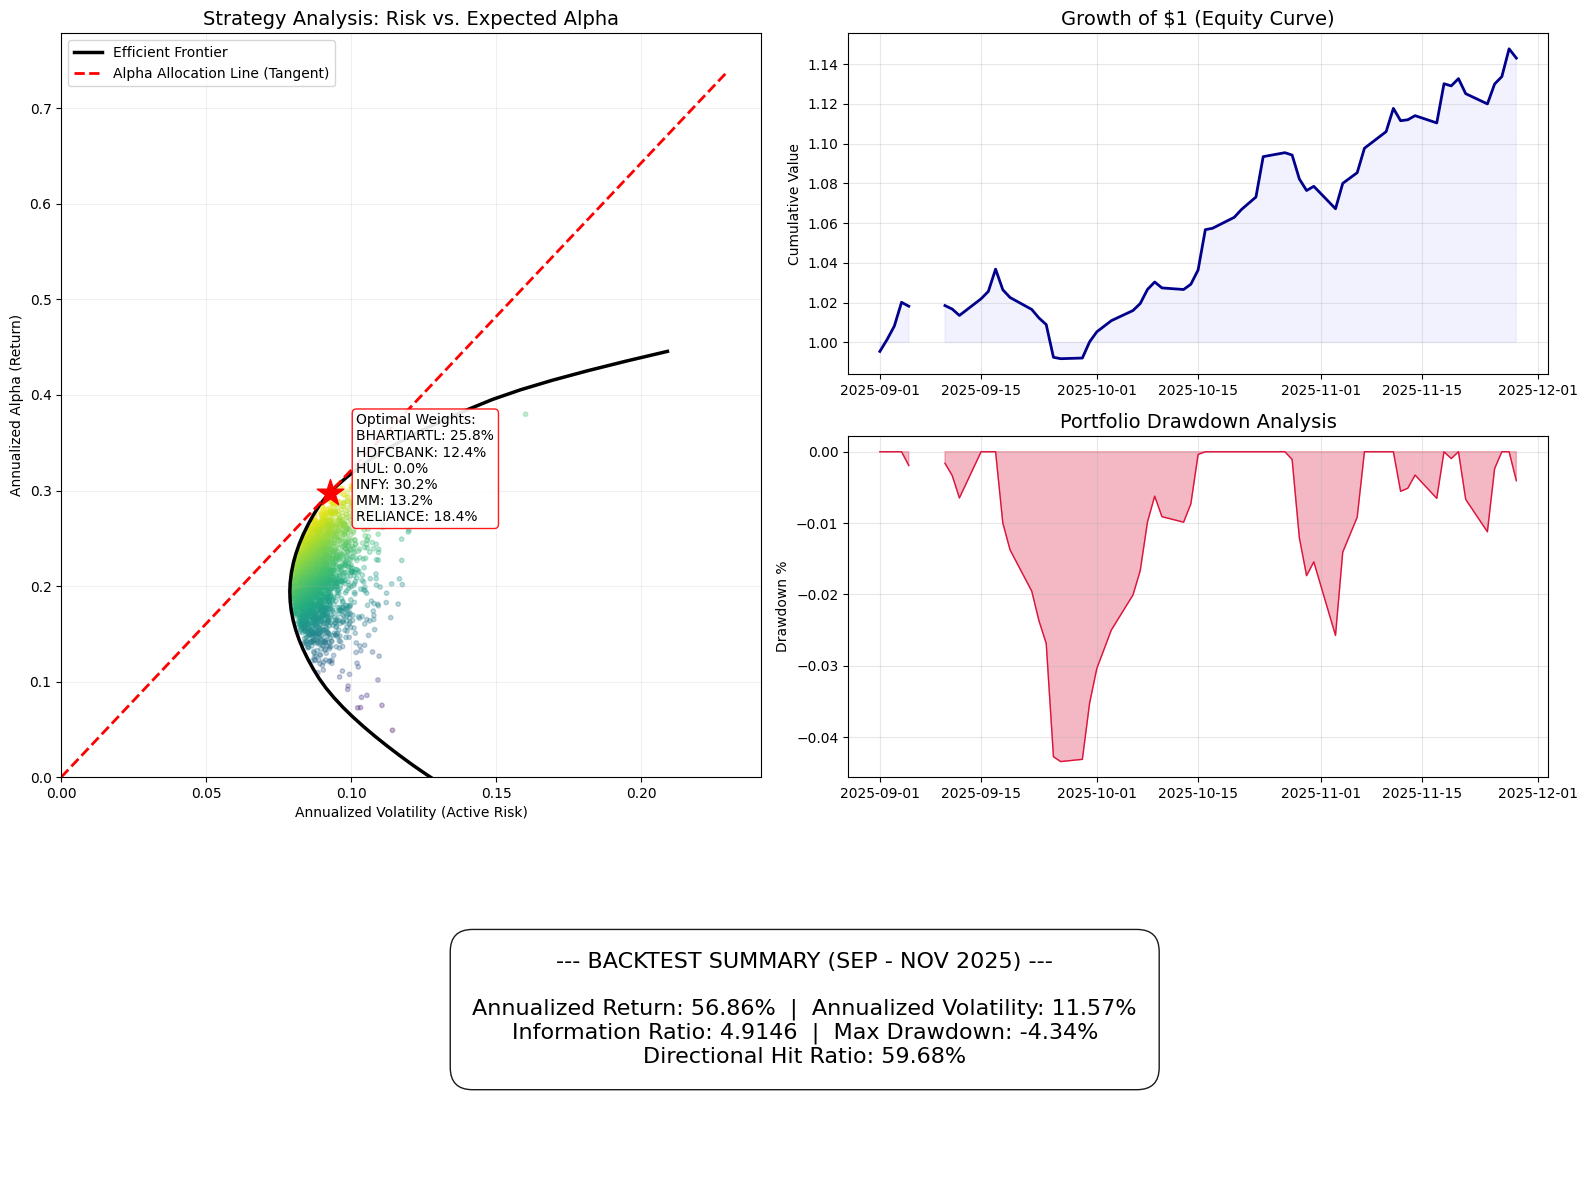


  AVERAGE PORTFOLIO WEIGHTS (OCT-DEC 2025)
INFY           : 22.02%
HDFCBANK       : 21.89%
BHARTIARTL     : 20.84%
MM             : 14.49%
RELIANCE       : 13.23%
HUL            : 7.53%


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURATION & DATA LOADING
# ==========================================
CSV_PATH = "merged_new_returns.csv"
TRADING_DAYS = 252
tickers = ['BHARTIARTL', 'HDFCBANK', 'HUL', 'INFY', 'MM', 'RELIANCE']
num_assets = len(tickers)

print("--- Step 1: Loading Data & Initializing Matrices ---")
try:
    df = pd.read_csv(CSV_PATH, index_col='Date', parse_dates=True).sort_index()
except FileNotFoundError:
    print(f"Error: {CSV_PATH} not found. Ensure the file is in your working directory.")
    raise

actual_wide = df[[f"{t}_Actual" for t in tickers]].copy()
pred_wide = df[[f"{t}_Predicted" for t in tickers]].copy()

actual_wide.columns = tickers
pred_wide.columns = tickers

mu_alpha_ann = pred_wide.mean().values * TRADING_DAYS
cov_mat_ann = LedoitWolf().fit(actual_wide.fillna(0).values).covariance_ * TRADING_DAYS

# ==========================================
# 2. CORE OPTIMIZATION ENGINES
# ==========================================
def get_port_stats(weights, mu, cov):
    ret = np.dot(weights, mu)
    vol = np.sqrt(max(np.dot(weights.T, np.dot(cov, weights)), 1e-12))
    return ret, vol

def optimize_max_ir(mu, cov):
    bounds = tuple((0.0, 1.0) for _ in range(num_assets))
    cons = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    init_guess = np.full(num_assets, 1.0 / num_assets)

    sol = minimize(lambda w: -(np.dot(w, mu) / (np.sqrt(w @ cov @ w) + 1e-9)),
                   init_guess, method='SLSQP', bounds=bounds, constraints=cons)
    return sol.x if sol.success else init_guess

print("--- Step 2: Generating Efficient Frontier Curve ---")
target_rets = np.linspace(mu_alpha_ann.min(), mu_alpha_ann.max(), 50)
ef_vols = []
for t_ret in target_rets:
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
            {'type': 'eq', 'fun': lambda w: np.dot(w, mu_alpha_ann) - t_ret})
    res = minimize(lambda w, cov: np.sqrt(w @ cov @ w),
                   np.full(num_assets, 1.0/num_assets),
                   method='SLSQP', bounds=[(0,1)]*num_assets,
                   constraints=cons, args=(cov_mat_ann,))
    ef_vols.append(res.fun if res.success else None)

# ==========================================
# 3. CALCULATE TANGENCY (MAX IR) PORTFOLIO
# ==========================================
opt_w_final = optimize_max_ir(mu_alpha_ann, cov_mat_ann)
opt_r, opt_v = get_port_stats(opt_w_final, mu_alpha_ann, cov_mat_ann)
max_ir_ratio = opt_r / opt_v

# Format the weights for the chart label
weights_label = "Optimal Weights:\n" + "\n".join([f"{t}: {w:.1%}" for t, w in zip(tickers, opt_w_final)])

# ==========================================
# 4. DAILY WALK-FORWARD BACKTEST
# ==========================================
print(f"--- Step 3: Running Backtest for {len(actual_wide)} days ---")
port_returns = []
all_weights = []

for dt in actual_wide.index:
    mu_daily = pred_wide.loc[dt].values
    w_daily = optimize_max_ir(mu_daily, cov_mat_ann)
    all_weights.append(w_daily)
    realized_ret = np.dot(w_daily, actual_wide.loc[dt].values)
    port_returns.append(realized_ret)

weights_df = pd.DataFrame(all_weights, index=actual_wide.index, columns=tickers)
strat_returns = pd.Series(port_returns, index=actual_wide.index)
cum_growth = (1 + strat_returns).cumprod()
peak = cum_growth.cummax()
drawdown = (cum_growth / peak) - 1.0

# ==========================================
# 5. INTEGRATED DASHBOARD VISUALIZATION
# ==========================================
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2)

# A. Efficient Frontier, Monte Carlo, & Tangent Line
ax1 = fig.add_subplot(gs[0:2, 0])
num_sim = 2500
mc_ret, mc_vol = [], []
for _ in range(num_sim):
    w = np.random.random(num_assets); w /= w.sum()
    r, v = get_port_stats(w, mu_alpha_ann, cov_mat_ann)
    mc_ret.append(r); mc_vol.append(v)

# Plot Monte Carlo Cloud
ax1.scatter(mc_vol, mc_ret, c=np.array(mc_ret)/np.array(mc_vol), cmap='viridis', s=10, alpha=0.3)

# Plot Efficient Frontier
valid_vols = [v for v in ef_vols if v]
valid_rets = [r for v, r in zip(ef_vols, target_rets) if v]
ax1.plot(valid_vols, valid_rets, color='black', linewidth=2.5, label='Efficient Frontier')

# Plot Alpha Allocation Line (Tangent Line starting from origin)
aal_x = np.linspace(0, max(valid_vols) * 1.1, 100)
aal_y = max_ir_ratio * aal_x
ax1.plot(aal_x, aal_y, color='red', linestyle='--', linewidth=2, label='Alpha Allocation Line (Tangent)')

# Plot Optimal Point & Add Label
ax1.scatter(opt_v, opt_r, color='red', marker='*', s=400, zorder=10)
ax1.annotate(weights_label,
             xy=(opt_v, opt_r),
             xytext=(opt_v * 1.1, opt_r * 0.9),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", lw=1, alpha=0.9),
             fontsize=10)

ax1.set_title("Strategy Analysis: Risk vs. Expected Alpha", fontsize=14)
ax1.set_xlabel("Annualized Volatility (Active Risk)")
ax1.set_ylabel("Annualized Alpha (Return)")
ax1.set_xlim(left=0) # Ensure origin is visible
ax1.set_ylim(bottom=0)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.2)

# B. Cumulative Wealth Plot ($1 growth)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(cum_growth.index, cum_growth.values, color='darkblue', linewidth=2)
ax2.fill_between(cum_growth.index, 1, cum_growth.values, color='blue', alpha=0.05)
ax2.set_title("Growth of $1 (Equity Curve)", fontsize=14)
ax2.set_ylabel("Cumulative Value")
ax2.grid(True, alpha=0.3)

# C. Drawdown Plot
ax3 = fig.add_subplot(gs[1, 1])
ax3.fill_between(drawdown.index, drawdown.values, 0, color='crimson', alpha=0.3)
ax3.plot(drawdown.index, drawdown.values, color='crimson', linewidth=1)
ax3.set_title("Portfolio Drawdown Analysis", fontsize=14)
ax3.set_ylabel("Drawdown %")
ax3.grid(True, alpha=0.3)

# D. Metric Summary Table
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')
ann_ret = strat_returns.mean() * TRADING_DAYS
ann_vol = strat_returns.std() * np.sqrt(TRADING_DAYS)
stats_text = (
    f"--- BACKTEST SUMMARY (SEP - NOV 2025) ---\n\n"
    f"Annualized Return: {ann_ret:.2%}  |  Annualized Volatility: {ann_vol:.2%}\n"
    f"Information Ratio: {ann_ret/ann_vol:.4f}  |  Max Drawdown: {drawdown.min():.2%}\n"
    f"Directional Hit Ratio: {(strat_returns > 0).mean():.2%}"
)
ax4.text(0.5, 0.5, stats_text, ha='center', va='center', fontsize=16,
         bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=1'))

plt.tight_layout()
plt.show()

# Print Final Averages to Console
print("\n" + "="*50)
print("  AVERAGE PORTFOLIO WEIGHTS (OCT-DEC 2025)")
print("="*50)
avg_weights = weights_df.mean().sort_values(ascending=False)
for ticker, weight in avg_weights.items():
    print(f"{ticker:<15}: {weight:.2%}")
print("="*50)